# Per-m leakage map of the RID 77450 symmetric MZ (π/2 beamsplitters fixed)

This notebook projects the atom onto the momentum/internal-state basis **after
every pulse** of the genuine ARTIQ RID 77450 symmetric Mach-Zehnder
(`DeclarativeLMTGlobalSymmetricMachZehnderFrag`) and plots the resulting
populations, so we can see exactly where population leaks out of the intended
interferometer path as the sequence progresses.

**Why this re-run exists.** It is a duplicate of
`population_leakage_by_m_rid76695`, run against a *new* pulse record captured
after the global-mode beamsplitter bug was fixed. In
[`population_leakage_by_m_rid76695`](./population_leakage_by_m_rid76695.py) and
LMT_sim PR #43 we found that RID 76695's dump contained **no π/2 pulses at
all**: in global-parameter mode `lmt_global_duration_attr` bound every
full-intensity pulse to the shared per-beam π duration regardless of
`event.area`, so the two beamsplitters `bs1`/`bs2` — declared `pi2` — physically
fired at the full **down-π** time (67 µs). icl_experiments PR #86 (commit
`8bc45727`, branch `declarative-lmt`) routes π/2 events to dedicated
`lmt_down_pi2_duration` / `lmt_up_pi2_duration` handles. RID 77450 re-runs the
RID 76695 sequence **with identical parameters** (`n_launch = 0`, `n_recoils =
2`, up-π 56 µs, down-π 67 µs, slice 380 µs, φ = 0) on the fixed branch, with the
lasers off / no atoms — its only purpose is to capture the corrected pulse
record. The decoded record below confirms the two down-beam beamsplitters
(pulses 1 and 19) now carry a **33.5 µs = down-π/2** duration instead of the
full 67 µs, so the sequence is at last a genuine Mach-Zehnder rather than the
single-occupied-path all-π walk of RID 76695.

**Readout convention.** The "probability of finding the atom in `(m, internal)`
if we projected right now" is the sim's own projective-measurement quantity,
`calculate_ground_and_excited_probabilities`: for each momentum class `m` the
amplitudes of all rows sharing `(m, internal)` are summed **coherently** and
squared,

$$P_\text{g}(m) = \Bigl|\sum_{\text{rows: }m,\,g} c\Bigr|^2, \qquad
  P_\text{e}(m) = \Bigl|\sum_{\text{rows: }m,\,e} c\Bigr|^2 .$$

This is frame-independent (all rows of one `(m, internal)` carry the same
Bordé-frame phase) and it is what a real clearout / detection would measure.
Because it is coherent, these populations genuinely reflect interference
between paths that recombine into the same `m`.

**Interferometry phase.** Set to **zero** here (`interferometer_phase = 0`):
pulses 10-18 would otherwise carry `φ` and pulse 19 `4φ` (the scanned MZ
phase), but for a *leakage* diagnostic the zero-phase configuration is the
clean baseline. Only the final recombination (last couple of pulses) depends
on the scan phase; the leakage during the mirror train does not.

**No clearouts.** The raw pulse sequence is run with no 461 nm clearouts, so
every bit of leaked population stays visible instead of being thrown away --
that is the point of the diagnostic.

In [1]:
import sys

sys.path.insert(0, "..")

import warnings
import dataclasses

import numpy as np
import matplotlib.pyplot as plt

import lmt_sim.lmt_sequence as seq
import lmt_sim.lmt_simulation as sim

## The RID 77450 pulse dump (interferometer_phase = 0 point)

Genuine float64 SI `pulse_record_flat` as emitted by `PulseDMARecording`. The
8th row (per-pulse interferometry phase) is all zeros at this scan point.

In [2]:
pulse_record_flat = np.array([
    20.0, 1.0, 0.0, 1.0, 1.0, 0.0,
    0.0, 0.0, 0.0, 1.0, 1.0, 0.0,
    1.0, 1.0, 0.0, 0.0, 0.0, 0.0,
    1.0, 1.0, 0.0, 0.0011392000000000002, 0.002142592, 0.002197812,
    0.002475548, 0.002603268, 0.002691988, 0.0028307080000000004, 0.0031194440000000003, 0.003258164,
    0.0033358840000000003, 0.003416128, 0.003504848, 0.0037825840000000003, 0.003910304, 0.003999024,
    0.0041377440000000005, 0.00442648, 0.0045652, 0.00464292, 0.004723168000000001, 0.000379999,
    3.35e-05, 5.5999000000000004e-05, 5.5999000000000004e-05, 6.7e-05, 6.7e-05, 6.7e-05,
    6.7e-05, 5.5999000000000004e-05, 5.5999000000000004e-05, 6.7e-05, 5.5999000000000004e-05, 5.5999000000000004e-05,
    6.7e-05, 6.7e-05, 6.7e-05, 6.7e-05, 5.5999000000000004e-05, 5.5999000000000004e-05,
    3.35e-05, 80014038.33602092, 79984677.23407157, 80009139.72161916, 80031843.41483626, 79996777.9422243,
    79957924.06945309, 79993584.53084627, 79951922.29819915, 80024027.78063032, 80043923.11397147, 79966560.74623615,
    80027491.3907797, 80050195.08399677, 79978426.27306378, 79939572.40029258, 79975232.86168575, 79933570.6290386,
    80042379.44979084, 80062274.78313199, 79948444.20223802, 200000000.0, 200000000.0, 200000000.0,
    200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0,
    200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0,
    200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0, 99426200.0,
    99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0,
    99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0,
    99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0,
    99426200.0, 0.012, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
])
pulse_record_offsets = np.array([0], dtype=np.int64)

dump = seq.decode_pulse_record_flat(pulse_record_flat, pulse_record_offsets)[0]
n_pulses = len(dump.is_up)
print(f"decoded {n_pulses} pulses; up/down = {dump.is_up.sum()}/{(~dump.is_up).sum()}")

# The fix in one line: pulses 1 and 19 (the down-beam beamsplitters) now carry a
# down-π/2 = 33.5 µs duration; every launch/mirror pulse stays a full π (up 56 µs,
# down 67 µs). In the buggy RID 76695 dump those same two pulses were 67 µs.
_durs_us = np.round(np.asarray(dump.durations_s) * 1e6, 2)
print("pulse durations (µs):", _durs_us)
_bs = np.where(np.isclose(_durs_us, 33.5, atol=1.0))[0]
print(f"beamsplitter (π/2, 33.5 µs) pulses at indices {_bs.tolist()} "
      f"-- down-beam: {(~dump.is_up[_bs]).all()}")
assert _bs.tolist() == [1, n_pulses - 1], "expected the two beamsplitters at pulses 1 and 19"

decoded 20 pulses; up/down = 9/11
pulse durations (µs): [380.   33.5  56.   56.   67.   67.   67.   67.   56.   56.   67.   56.
  56.   67.   67.   67.   67.   56.   56.   33.5]
beamsplitter (π/2, 33.5 µs) pulses at indices [1, 19] -- down-beam: True


## Build the sequence (calibrated, phase = 0, no clearouts)

`calibrate_probe_shift_and_velocity_from_dump` reverse-engineers the AC-Stark
coefficient and initial velocity that put every recorded pulse on its intended
recoil rung (a self-consistent fit -- it warns loudly; suppressed here for
readability). The build then folds the free-fall Doppler shift into the
recorded detunings, so the quantum run is done at v = 0.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    alpha, v0 = seq.calibrate_probe_shift_and_velocity_from_dump(
        **dataclasses.asdict(dump)
    )
print(f"probe-shift alpha = {alpha:.4g} 1/Hz   initial velocity = {v0 * 1e3:+.3f} mm/s")

_timestamps, sequence = seq.build_sequence_from_lab_pulse_dump(
    **dataclasses.asdict(dump),
    probe_induced_alpha_up=alpha,
    probe_induced_alpha_down=alpha,
    initial_velocity_z=v0,
)
pulse_events = [e for e in sequence if isinstance(e, seq.Pulse)]
assert len(pulse_events) == n_pulses

probe-shift alpha = -1.708e-05 1/Hz   initial velocity = -0.034 mm/s


## Project after every pulse

`iter_pulse_sequence_in_borde_representation` yields the state before the first
event and after every event. We keep the snapshot taken immediately after each
`Pulse` (free-fall between pulses does not change the `(m, internal)`
populations, only their phases and positions), giving one momentum spectrum per
pulse index 0..19.

In [4]:
def coherent_populations_by_m(state):
    """Return {m: P_ground(m)}, {m: P_excited(m)} using the coherent per-m sum."""
    p_ground, p_excited = {}, {}
    for m in np.unique(state.m_values):
        same_m = state.m_values == m
        g = same_m & state.internal_is_ground
        e = same_m & ~state.internal_is_ground
        p_ground[int(m)] = float(np.abs(state.amplitudes[g].sum()) ** 2)
        p_excited[int(m)] = float(np.abs(state.amplitudes[e].sum()) ** 2)
    return p_ground, p_excited


# Snapshot after every event, then keep the ones that follow a Pulse.
initial = sim.make_atom_states(c0=1, c1=0, initial_velocity_z=0.0)
snapshots = list(
    seq.iter_pulse_sequence_in_borde_representation(
        initial, sequence, initial_velocity_z=0.0, discard_threshold=1e-12
    )
)
# snapshots[0] is the initial state; snapshots[i + 1] is after sequence[i].
per_pulse_ground = []
per_pulse_excited = []
for i, event in enumerate(sequence):
    if isinstance(event, seq.Pulse):
        state = snapshots[i + 1][0]
        pg, pe = coherent_populations_by_m(state)
        per_pulse_ground.append(pg)
        per_pulse_excited.append(pe)

assert len(per_pulse_ground) == n_pulses

# Assemble dense (n_pulses x n_m) probability matrices on a shared m-grid.
all_m = sorted(
    {m for d in (per_pulse_ground + per_pulse_excited) for m in d}
)
m_index = {m: j for j, m in enumerate(all_m)}
ground_mat = np.zeros((n_pulses, len(all_m)))
excited_mat = np.zeros((n_pulses, len(all_m)))
for p in range(n_pulses):
    for m, val in per_pulse_ground[p].items():
        ground_mat[p, m_index[m]] = val
    for m, val in per_pulse_excited[p].items():
        excited_mat[p, m_index[m]] = val

total_per_pulse = ground_mat.sum(axis=1) + excited_mat.sum(axis=1)
print(f"m classes populated across the sequence: {all_m[0]} .. {all_m[-1]}")
print(f"total projected probability per pulse: min {total_per_pulse.min():.3f}, "
      f"max {total_per_pulse.max():.3f} (coherent readout conserves probability)")

m classes populated across the sequence: -7 .. 9
total projected probability per pulse: min 1.000, max 1.000 (coherent readout conserves probability)


## The leakage map -- populations by m, swept pulse by pulse

Two panels (ground, excited). **x = momentum class m, y = projection
probability.** One line per pulse, coloured from dark (early pulses) to bright
(late pulses), so you can watch population get pumped up the recoil ladder and
see where it spills into unintended classes.

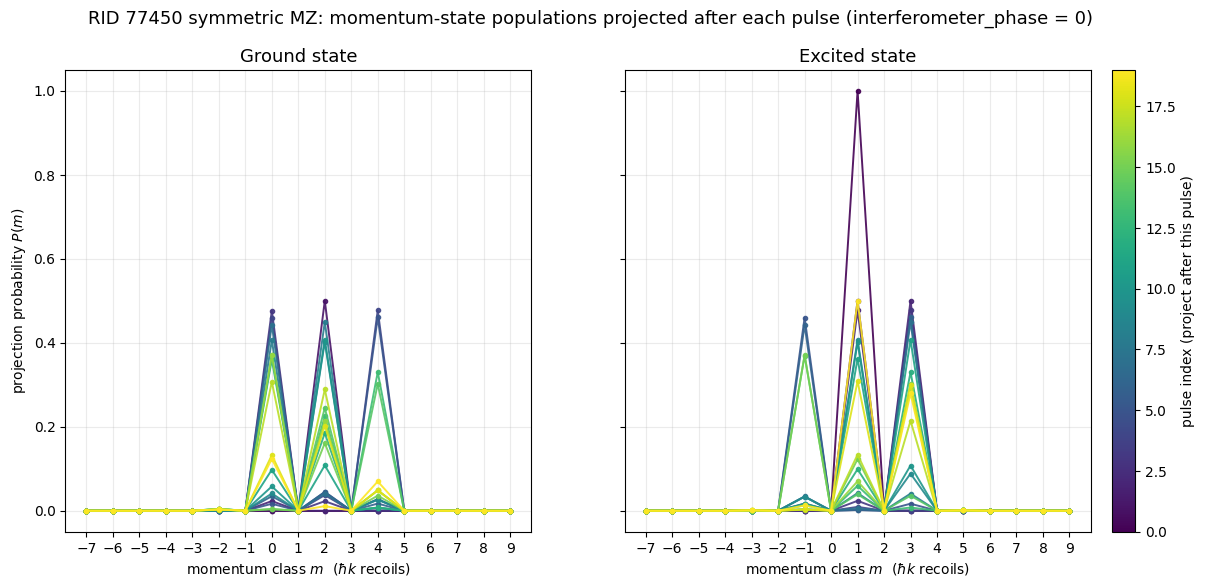

In [5]:
m_arr = np.array(all_m)
cmap = plt.get_cmap("viridis")
colors = [cmap(p / (n_pulses - 1)) for p in range(n_pulses)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, mat, title in (
    (axes[0], ground_mat, "Ground state"),
    (axes[1], excited_mat, "Excited state"),
):
    for p in range(n_pulses):
        ax.plot(m_arr, mat[p], color=colors[p], lw=1.4, marker="o", ms=3, alpha=0.9)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("momentum class $m$  ($\\hbar k$ recoils)")
    ax.grid(alpha=0.25)
    ax.set_xticks(m_arr)
axes[0].set_ylabel("projection probability $P(m)$")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n_pulses - 1))
cbar = fig.colorbar(sm, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label("pulse index (project after this pulse)")
fig.suptitle(
    "RID 77450 symmetric MZ: momentum-state populations projected after each pulse "
    "(interferometer_phase = 0)",
    fontsize=13,
)
plt.show()

## Same data as heatmaps

A complementary view: pulse index on the vertical axis, momentum on the
horizontal, colour = projection probability. Rows read top-to-bottom as the
sequence advances; bright horizontal streaks are where population parks.

The colour is on a **logarithmic** scale so the weak parasitic paths -- the
few-times-$10^{-3}$ population that off-resonant transfer spills into
unintended `m` classes -- are visible alongside the near-unity main streak. A
linear scale washes them out entirely. Probabilities below ``FLOOR`` (and the
exact zeros) are clipped to the darkest colour.

## Intended interferometer path (overlaid to guide the eye)

The next figure overlays the **intended** Mach-Zehnder arm trajectories on the
leakage heatmap. The intended path is found by walking an ideal on-axis atom
through the sequence and letting each pulse **flip**, **drift**, or **split**
according to its Rabi area — the same rule `compute_spacetime_trajectory` uses:
a π pulse flips, a π/2 pulse splits. For **this** RID the two beamsplitters are
genuine π/2 in the record, so the split falls straight out of the recorded
durations (`force_bs_pi2=False`) — the intended path should land right on the
bright population streaks.

In [6]:
def intended_arm_trajectories(dump, force_bs_pi2, flip_threshold=0.75):
    """Intended MZ arms: list of dicts {pulse_index: (m, is_ground)}.

    Walks an ideal on-axis atom through the sequence, splitting at π/2 and
    flipping at π (the `compute_spacetime_trajectory` rule). If ``force_bs_pi2``
    the two beamsplitters (pulses 1 and n-1) are set to a down-π/2 duration
    first, so the intended split is shown even for a record in which they fired
    as full π (RID 76695); for a record that already holds π/2 beamsplitters
    (RID 77450) pass ``force_bs_pi2=False``.
    """
    d = dump
    n = len(d.is_up)
    if force_bs_pi2:
        dur = np.array(d.durations_s)
        for b in (1, n - 1):
            dur[b] = 33.5e-6  # down-π/2 = half the 67 µs down-π
        d = dataclasses.replace(d, durations_s=dur)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        alpha, v0 = seq.calibrate_probe_shift_and_velocity_from_dump(
            **dataclasses.asdict(d)
        )
    _t, sequence = seq.build_sequence_from_lab_pulse_dump(
        **dataclasses.asdict(d),
        probe_induced_alpha_up=alpha,
        probe_induced_alpha_down=alpha,
        initial_velocity_z=v0,
    )
    pulses = [e for e in sequence if isinstance(e, seq.Pulse)]
    arms = [{"m": 0, "g": True, "hist": {}, "cid": 0}]
    first_split_done = False
    for p, pl in enumerate(pulses):
        nxt = []
        for a in arms:
            pr = seq._transition_probability(a["m"], a["g"], pl)
            if pr >= flip_threshold:
                a["m"] += pl.k if a["g"] else -pl.k
                a["g"] = not a["g"]
                a["hist"][p] = (a["m"], a["g"])
                nxt.append(a)
            elif pr <= 1 - flip_threshold:
                a["hist"][p] = (a["m"], a["g"])
                nxt.append(a)
            else:  # π/2 → split into a drifter and a flipper
                # The input splitter (bs1) creates the two interferometer arms
                # (distinct colours); the recombiner's forks inherit their arm.
                b_cid = 1 if not first_split_done else a["cid"]
                first_split_done = True
                b = {"m": a["m"], "g": a["g"], "hist": dict(a["hist"]), "cid": b_cid}
                a["hist"][p] = (a["m"], a["g"])
                b["m"] += pl.k if b["g"] else -pl.k
                b["g"] = not b["g"]
                b["hist"][p] = (b["m"], b["g"])
                nxt.extend([a, b])
        arms = nxt
    return [(a["hist"], a["cid"]) for a in arms]


def overlay_intended_path(ax_ground, ax_excited, arms):
    """Draw the intended arm momentum trajectories on the two heatmap panels.

    Each arm's ``m(pulse)`` line is drawn on both panels; a bold hollow ring
    marks each pulse where the arm occupies THAT panel's internal state, a faint
    dot where it is in the other. A ring on a bright cell = the sequence did what
    it intended; a ring over a dark cell = intended population that never arrived
    (the signature of the buggy all-π run whose beamsplitters failed to split).
    """
    from matplotlib.lines import Line2D

    arm_colors = ["#00e5ff", "#7CFC00"]
    for hist, cid in arms:
        ps = np.array(sorted(hist))
        m = np.array([hist[p][0] for p in ps])
        g = np.array([hist[p][1] for p in ps])
        c = arm_colors[cid % len(arm_colors)]
        for ax, want_ground in ((ax_ground, True), (ax_excited, False)):
            ax.plot(m, ps, color=c, lw=1.5, alpha=0.85, zorder=5)
            sel = g == want_ground
            ax.scatter(m[sel], ps[sel], s=64, facecolors="none",
                       edgecolors=c, linewidths=2.0, zorder=6)
            ax.scatter(m[~sel], ps[~sel], s=12, c=c, alpha=0.30, zorder=6)
    handles = [
        Line2D([0], [0], color="#00e5ff", lw=1.5, marker="o", markerfacecolor="none",
               markeredgecolor="#00e5ff", markersize=8, label="intended MZ arms"),
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="none",
               markeredgecolor="0.2", markersize=8, label="arm occupies this state here"),
    ]
    ax_ground.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.85)


intended_arms = intended_arm_trajectories(dump, force_bs_pi2=False)
print(f"intended MZ arms: {len(intended_arms)} "
      f"(2 between the beamsplitters; the recombiner splits them to 4 output ports)")

intended MZ arms: 4 (2 between the beamsplitters; the recombiner splits them to 4 output ports)


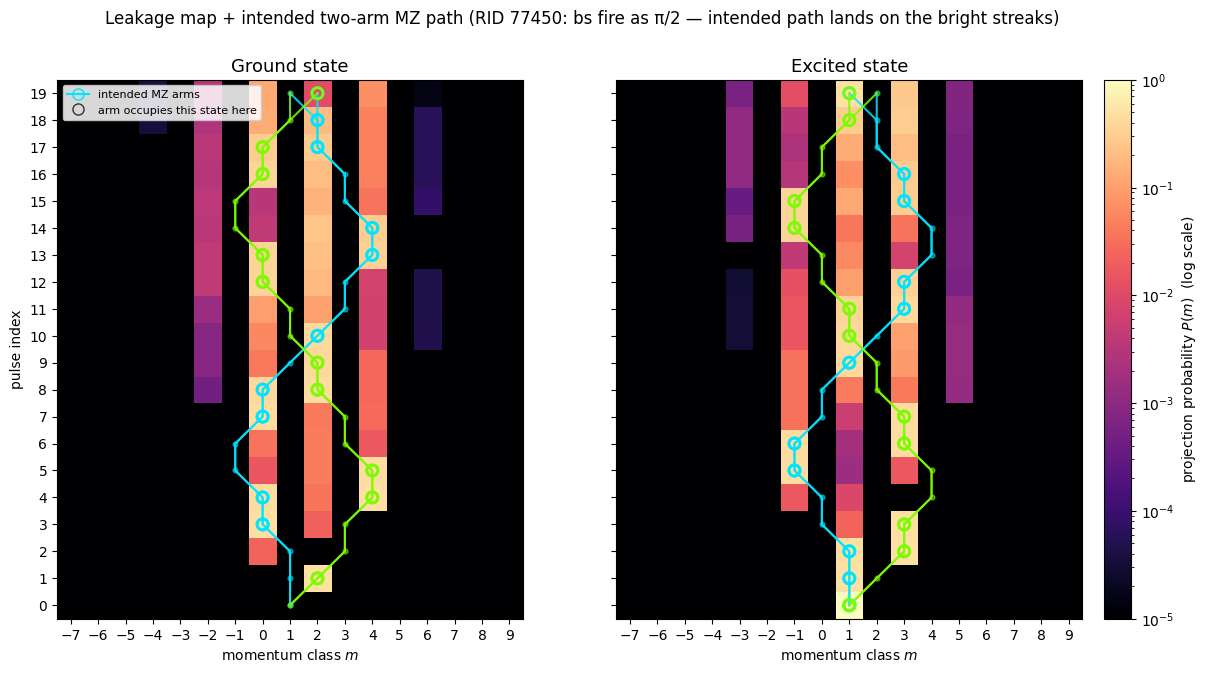

In [7]:
from matplotlib.colors import LogNorm  # noqa: E402
import matplotlib as mpl  # noqa: E402

FLOOR = 1e-5  # lower end of the log colour scale (5 decades down from ~1)
log_cmap = mpl.colormaps["magma"].copy()
log_cmap.set_bad(log_cmap(0.0))  # exact-zero cells render as the low-end colour

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
norm = LogNorm(vmin=FLOOR, vmax=1.0)
for ax, mat, title in (
    (axes[0], ground_mat, "Ground state"),
    (axes[1], excited_mat, "Excited state"),
):
    masked = np.where(mat > 0, mat, np.nan)  # keep true zeros out of the log
    im = ax.imshow(
        masked,
        aspect="auto",
        origin="lower",
        cmap=log_cmap,
        norm=norm,
        extent=[m_arr[0] - 0.5, m_arr[-1] + 0.5, -0.5, n_pulses - 0.5],
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("momentum class $m$")
    ax.set_xticks(m_arr)
axes[0].set_ylabel("pulse index")
axes[0].set_yticks(range(n_pulses))
overlay_intended_path(axes[0], axes[1], intended_arms)
cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label("projection probability $P(m)$  (log scale)")
fig.suptitle(
    "Leakage map + intended two-arm MZ path (RID 77450: bs fire as π/2 — "
    "intended path lands on the bright streaks)",
    fontsize=12,
)
plt.show()

## Overall book-keeping: ground/excited split and total vs pulse

How the total ground and excited probability evolve, and confirmation that the
coherent projective readout conserves total probability (there are no clearouts
to remove any).

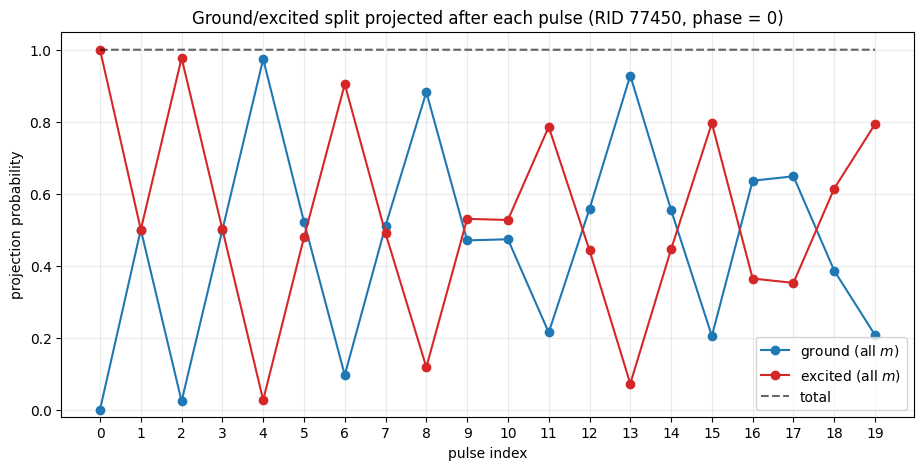

In [8]:
ground_total = ground_mat.sum(axis=1)
excited_total = excited_mat.sum(axis=1)
pulses = np.arange(n_pulses)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pulses, ground_total, "-o", label="ground (all $m$)", color="tab:blue")
ax.plot(pulses, excited_total, "-o", label="excited (all $m$)", color="tab:red")
ax.plot(pulses, total_per_pulse, "--", label="total", color="k", alpha=0.6)
ax.set_xlabel("pulse index")
ax.set_ylabel("projection probability")
ax.set_xticks(pulses)
ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.25)
ax.legend()
ax.set_title("Ground/excited split projected after each pulse (RID 77450, phase = 0)")
plt.show()

### Reading the map

* Pulse 0 is the 380 us velocity-selection pulse: it drives the selected slice
  from `|g, 0>` to `|e, +1>`, so straight after it the population sits almost
  entirely in the `m = +1` excited class.
* **Pulse 1 is now a real π/2 beamsplitter.** The ground/excited split panel
  shows it landing at exactly 0.5 / 0.5 — the atom is genuinely put into a
  superposition of two momentum arms, which is the whole point of a
  Mach-Zehnder and is precisely what the RID 76695 (pre-fix) dump could not do:
  there `bs1` was a full π, so it simply flipped `|e,+1> -> |g,0>` and the
  sequence walked a single occupied path. The recombiner (pulse 19) is likewise
  a π/2 now.
* The mirror train then walks both arms up/down the recoil ladder; population
  is spread coherently across the `m = 0,2,4` (ground) and `m = 1,3` (excited)
  classes — the two interfering arms.
* Any probability that appears in an `m` the intended arms never visit is
  **leakage** -- off-resonant transfer that a perfect sequence would not
  produce. The log heatmap still shows faint streaks into `m = -2,-3,-4,5,6` at
  the `~10^-3`-`10^-4` level.

### What the fix did (and did not) change

Fixing the beamsplitters is necessary for the sequence to be an interferometer
at all, but it is **orthogonal** to the leakage mechanism diagnosed in
`population_leakage_by_m_rid76695` / LMT_sim PR #43. That leakage came from the
full-**π** launch/mirror pulses tuned to the *other* arm's (unpopulated) rungs
off-resonantly driving the occupied rung — a square-pulse limitation that the
beamsplitter-duration fix leaves untouched, so the faint parasitic streaks
survive here. The qualitative change is that the population now lives in a
genuine two-arm superposition (visible as the 50/50 split at pulse 1 and the
spread across the recoil ladder) rather than the single-path all-π walk of RID
76695. Reducing the residual leakage still needs the mitigations noted there:
"magic" π durations satisfying √(Ω²+δ²)·T = integer, or shaped / ARP pulses.

Because the interferometry phase is zero here, the final-pulse recombination
lands in one particular set of ports; sweeping the scan phase (pulses 10-18
get `φ`, pulse 19 gets `4φ`) redistributes population **only among the
recombining classes** and leaves this leakage picture otherwise unchanged.